# SNAPflow v2: Burst-Based InSAR Notebook

This notebook replaces the full-SLC download stage with a Sentinel-1 burst workflow built on `phidown`.

It follows this sequence:
- search and validate burst coverage with `run_burst_workflow(...)`
- select a compatible burst pair automatically, or use manual UUID overrides
- download the selected bursts through the CDSE burst on-demand endpoint
- extract each archive to a single local `.SAFE` product
- orbit-correct each burst independently, then run burst-native SNAPFlow processing

Processing differs from the original `snapflow.ipynb` in two important ways:
- the inputs are already single bursts, so the notebook does **not** run `TOPSAR-Split`
- pair coregistration runs with `use_esd=False`, because ESD is not appropriate for single-burst processing


In [1]:
from pathlib import Path
import json
import os

import pandas as pd
from dotenv import load_dotenv
from IPython.display import Image, display

from phidown import plot_product_footprints, run_burst_workflow
from phidown.downloader import download_burst_on_demand, get_token

from sarpyx.snapflow.burst_utils import extract_burst_archive, select_burst_pair
from sarpyx.snapflow.engine import GPT

pd.set_option("display.max_columns", None)

NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
REPO_ROOT = NOTEBOOK_DIR.parent
load_dotenv(REPO_ROOT / ".env")
DATA_DIR = REPO_ROOT / "data"
BURST_DIR = DATA_DIR / "bursts"
OUTPUT_DIR = DATA_DIR / "output" / "snapflow_v2"
STATS_DIR = OUTPUT_DIR / "burst_search"
PROCESS_DIR = OUTPUT_DIR / "processing"
SNAP_USERDIR = Path(os.getenv("SNAP_USERDIR", REPO_ROOT / ".snap"))
SNAP_TMPDIR = Path(os.getenv("SNAP_TMPDIR", REPO_ROOT / ".tmp" / "snapflow_v2"))
DEFAULT_GPT_PATH = Path("/shared/home/rdelprete/esa-snap/bin/gpt")
if os.getenv("GPT_PATH"):
    GPT_PATH = Path(os.getenv("GPT_PATH"))
elif DEFAULT_GPT_PATH.exists():
    GPT_PATH = DEFAULT_GPT_PATH
else:
    GPT_PATH = Path("/usr/local/snap/bin/gpt")

def first_env(*names: str) -> str | None:
    for name in names:
        value = os.getenv(name)
        if value:
            return value
    return None

CDSE_USERNAME = first_env("CDSE_USERNAME", "CDSE_USR")
CDSE_PASSWORD = first_env("CDSE_PASSWORD", "CDSE_PSW")

for path in (DATA_DIR, BURST_DIR, OUTPUT_DIR, STATS_DIR, PROCESS_DIR, SNAP_USERDIR, SNAP_TMPDIR):
    path.mkdir(parents=True, exist_ok=True)

os.environ["TMPDIR"] = SNAP_TMPDIR.as_posix()
java_tmp_opt = f"-Djava.io.tmpdir={SNAP_TMPDIR.as_posix()}"
existing_java_tool_options = os.getenv("JAVA_TOOL_OPTIONS", "").strip()
if java_tmp_opt not in existing_java_tool_options.split():
    merged = f"{existing_java_tool_options} {java_tmp_opt}".strip()
    os.environ["JAVA_TOOL_OPTIONS"] = merged

print(json.dumps({
    "repo_root": REPO_ROOT.as_posix(),
    "burst_dir": BURST_DIR.as_posix(),
    "output_dir": OUTPUT_DIR.as_posix(),
    "stats_dir": STATS_DIR.as_posix(),
    "process_dir": PROCESS_DIR.as_posix(),
    "gpt_path": GPT_PATH.as_posix(),
    "gpt_exists": GPT_PATH.exists(),
    "snap_userdir": SNAP_USERDIR.as_posix(),
    "snap_tmpdir": SNAP_TMPDIR.as_posix(),
    "has_cdse_username": bool(CDSE_USERNAME),
    "has_cdse_password": bool(CDSE_PASSWORD),
}, indent=2))


{
  "repo_root": "/shared/home/rdelprete/PythonProjects/srp",
  "burst_dir": "/shared/home/rdelprete/PythonProjects/srp/data/bursts",
  "output_dir": "/shared/home/rdelprete/PythonProjects/srp/data/output/snapflow_v2",
  "stats_dir": "/shared/home/rdelprete/PythonProjects/srp/data/output/snapflow_v2/burst_search",
  "process_dir": "/shared/home/rdelprete/PythonProjects/srp/data/output/snapflow_v2/processing",
  "gpt_path": "/shared/home/rdelprete/esa-snap/bin/gpt",
  "gpt_exists": true,
  "snap_userdir": "/shared/home/rdelprete/PythonProjects/srp/.snap",
  "snap_tmpdir": "/shared/home/rdelprete/PythonProjects/srp/.tmp/snapflow_v2",
  "has_cdse_username": true,
  "has_cdse_password": true
}


## Burst Search Configuration

Set the AOI and time window first. Burst data is available from **2024-08-02** onward.

Leave `MASTER_BURST_UUID` and `SLAVE_BURST_UUID` as `None` to auto-select the best compatible pair from the search results.


In [2]:
AOI_WKT = "POLYGON((12.4 41.8, 12.6 41.8, 12.6 42.0, 12.4 42.0, 12.4 41.8))"

MASTER_BURST_UUID = None
SLAVE_BURST_UUID = None

SEARCH_CONFIG = {
    "search": {
        "aoi_wkt": AOI_WKT,
        "start_date": "2025-01-01T00:00:00",
        "end_date": "2025-03-01T00:00:00",
        "polarisation": "VV",
        "orbit_direction": None,
        "relative_orbit": None,
        "platforms": ["all"],
        "swath_identifier": None,
        "burst_id": None,
        "max_results": 300,
    },
    "output_statistics": STATS_DIR.as_posix(),
    "save_results_csv": True,
}

print(json.dumps(SEARCH_CONFIG, indent=2))


{
  "search": {
    "aoi_wkt": "POLYGON((12.4 41.8, 12.6 41.8, 12.6 42.0, 12.4 42.0, 12.4 41.8))",
    "start_date": "2025-01-01T00:00:00",
    "end_date": "2025-03-01T00:00:00",
    "polarisation": "VV",
    "orbit_direction": null,
    "relative_orbit": null,
    "platforms": [
      "all"
    ],
    "swath_identifier": null,
    "burst_id": null,
    "max_results": 300
  },
  "output_statistics": "/shared/home/rdelprete/PythonProjects/srp/data/output/snapflow_v2/burst_search",
  "save_results_csv": true
}


## Run `phidown` Burst Workflow

This mirrors the upstream burst validation notebook: search, orbit recommendation, temporal statistics, validation, and footprint QA all happen before any burst download or SNAP processing.


In [3]:
result = run_burst_workflow(SEARCH_CONFIG)

df = result["df"]
stats = result["stats"]
validation = result["validation"]
debug = result["debug"]
orbit = result.get("orbit") or {}
paths = result.get("paths") or {}

print("Rows:", len(df))
print("Orbit:", orbit)
print("Validation:", validation)
print("Output files:", {k: str(v) for k, v in paths.items()})


INFO:phidown.search:Analyzing ASCENDING orbits...


INFO:phidown.search:Analyzing DESCENDING orbits...


INFO:phidown.search:Analyzing ASCENDING orbits...


INFO:phidown.search:Analyzing DESCENDING orbits...


Rows: 8
Orbit: {'analysis': {'ascending': {'orbits': {117: {'avg_coverage': 100.0, 'max_coverage': 100.0, 'count': 4}}, 'best_orbit': 117, 'max_coverage': 100.0}, 'descending': {'orbits': {22: {'avg_coverage': 82.79, 'max_coverage': 97.62, 'count': 10}, 95: {'avg_coverage': 63.63, 'max_coverage': 100.0, 'count': 10}}, 'best_orbit': 22, 'max_coverage': 82.79}, 'recommended': {'orbit_direction': 'ASCENDING', 'relative_orbit': 117, 'expected_coverage': 100.0}}, 'orbit_direction': 'ASCENDING', 'relative_orbit': 117}
Validation: {'ok': True, 'errors': [], 'warnings': []}
Output files: {'search_results_csv': '/shared/home/rdelprete/PythonProjects/srp/data/output/snapflow_v2/burst_search/search_results.csv', 'temporal_statistics_json': '/shared/home/rdelprete/PythonProjects/srp/data/output/snapflow_v2/burst_search/temporal_statistics.json', 'validation_report_json': '/shared/home/rdelprete/PythonProjects/srp/data/output/snapflow_v2/burst_search/validation_report.json', 'debug_summary_json': '

,@odata.mediaContentType,Id,Name,ContentType,S3Path,ContentDate,Footprint,GeoFootprint,ParentProductId,ParentProductName,ByteOffset,BurstId,AbsoluteBurstId,AzimuthTime,AzimuthAnxTime,ParentProductType,SwathIdentifier,RelativeOrbitNumber,OrbitDirection,PlatformSerialIdentifier,PolarisationChannels,OperationalMode,DatatakeID,Lines,LinesPerBurst,SamplesPerBurst,BeginningDateTime,EndingDateTime,coverage,subswath_priority
0,application/octet-stream,8ff4f2b3-64d8-4852-8c3b-4b2b8f729b03,S1A-SLC-20250217T170613-249406-IW2-VV-468546,application/octet-stream,/eodata/Sentinel-1/SAR/IW_SLC__1S/2025/02/17/S...,"{'Start': '2025-02-17T17:06:13.727886Z', 'End'...",geography'SRID=4326;POLYGON ((11.92971 41.8071...,"{'type': 'Polygon', 'coordinates': [[[11.92971...",99c31c4e-0ed9-415d-bc59-393c9f753e1d,S1A_IW_SLC__1SDV_20250217T170559_20250217T1706...,640810107,249406,124446891,2025-02-17T17:06:12.711058Z,678.918613,IW_SLC__1S,IW2,117,ASCENDING,A,VV,IW,468546,6048,1512,26484,2025-02-17T17:06:13.727886Z,2025-02-17T17:06:14.769476Z,59.83,1
1,application/octet-stream,2404a519-5e05-4dcc-95e5-b3e4e8a79127,S1A-SLC-20250205T170614-249406-IW2-VV-466741,application/octet-stream,/eodata/Sentinel-1/SAR/IW_SLC__1S/2025/02/05/S...,"{'Start': '2025-02-05T17:06:14.317745Z', 'End'...",geography'SRID=4326;POLYGON ((11.92971 41.8071...,"{'type': 'Polygon', 'coordinates': [[[11.92971...",cf6f847b-0634-4f93-b38f-a4d38b69bef9,S1A_IW_SLC__1SDV_20250205T170559_20250205T1706...,800997435,249406,124071003,2025-02-05T17:06:13.305030Z,678.925139,IW_SLC__1S,IW2,117,ASCENDING,A,VV,IW,466741,7560,1512,26484,2025-02-05T17:06:14.317745Z,2025-02-05T17:06:15.359335Z,59.83,1
2,application/octet-stream,ed949647-6573-484a-a49c-913d80e51117,S1A-SLC-20250124T170614-249406-IW2-VV-464973,application/octet-stream,/eodata/Sentinel-1/SAR/IW_SLC__1S/2025/01/24/S...,"{'Start': '2025-01-24T17:06:14.811016Z', 'End'...",geography'SRID=4326;POLYGON ((11.92971 41.8071...,"{'type': 'Polygon', 'coordinates': [[[11.92971...",21332892-321f-4954-b01e-6247318c0c60,S1A_IW_SLC__1SDV_20250124T170600_20250124T1706...,640810107,249406,123695116,2025-01-24T17:06:13.792121Z,678.918260,IW_SLC__1S,IW2,117,ASCENDING,A,VV,IW,464973,6048,1512,26484,2025-01-24T17:06:14.811016Z,2025-01-24T17:06:15.852606Z,59.83,1
3,application/octet-stream,cedb52f3-9e96-49b9-a6a3-d7b195c6918e,S1A-SLC-20250112T170615-249406-IW2-VV-463192,application/octet-stream,/eodata/Sentinel-1/SAR/IW_SLC__1S/2025/01/12/S...,"{'Start': '2025-01-12T17:06:15.657009Z', 'End'...",geography'SRID=4326;POLYGON ((11.92971 41.8071...,"{'type': 'Polygon', 'coordinates': [[[11.92971...",6b19852e-76d9-4d8f-872d-1e454a903b10,S1A_IW_SLC__1SDV_20250112T170601_20250112T1706...,640810107,249406,123319229,2025-01-12T17:06:14.638116Z,678.920017,IW_SLC__1S,IW2,117,ASCENDING,A,VV,IW,463192,6048,1512,26484,2025-01-12T17:06:15.657009Z,2025-01-12T17:06:16.698599Z,59.83,1
4,application/octet-stream,ead48acc-c11b-418b-9aac-a550d8eee23f,S1A-SLC-20250217T170610-249405-IW2-VV-468546,application/octet-stream,/eodata/Sentinel-1/SAR/IW_SLC__1S/2025/02/17/S...,"{'Start': '2025-02-17T17:06:10.969609Z', 'End'...",geography'SRID=4326;POLYGON ((11.970216 41.641...,"{'type': 'Polygon', 'coordinates': [[[11.97021...",99c31c4e-0ed9-415d-bc59-393c9f753e1d,S1A_IW_SLC__1SDV_20250217T170559_20250217T1706...,480634875,249405,124446890,2025-02-17T17:06:09.958669Z,676.166224,IW_SLC__1S,IW2,117,ASCENDING,A,VV,IW,468546,4536,1512,26484,2025-02-17T17:06:10.969609Z,2025-02-17T17:06:12.011199Z,51.88,1
5,application/octet-stream,dee9e6c1-b963-49a6-82ff-fed6581814b4,S1A-SLC-20250205T170611-249405-IW2-VV-466741,application/octet-stream,/eodata/Sentinel-1/SAR/IW_SLC__1S/2025/02/05/S...,"{'Start': '2025-02-05T17:06:11.559468Z', 'End'...",geography'SRID=4326;POLYGON ((11.970216 41.641...,"{'type': 'Polygon', 'coordinates': [[[11.97021...",cf6f847b-0634-4f93-b38f-a4d38b69bef9,S1A_IW_SLC__1SDV_20250205T170559_20250205T1706...,640822203,249405,124071002,2025-02-05T17:06:10.552640Z,676.172749,IW_SLC__1S,IW

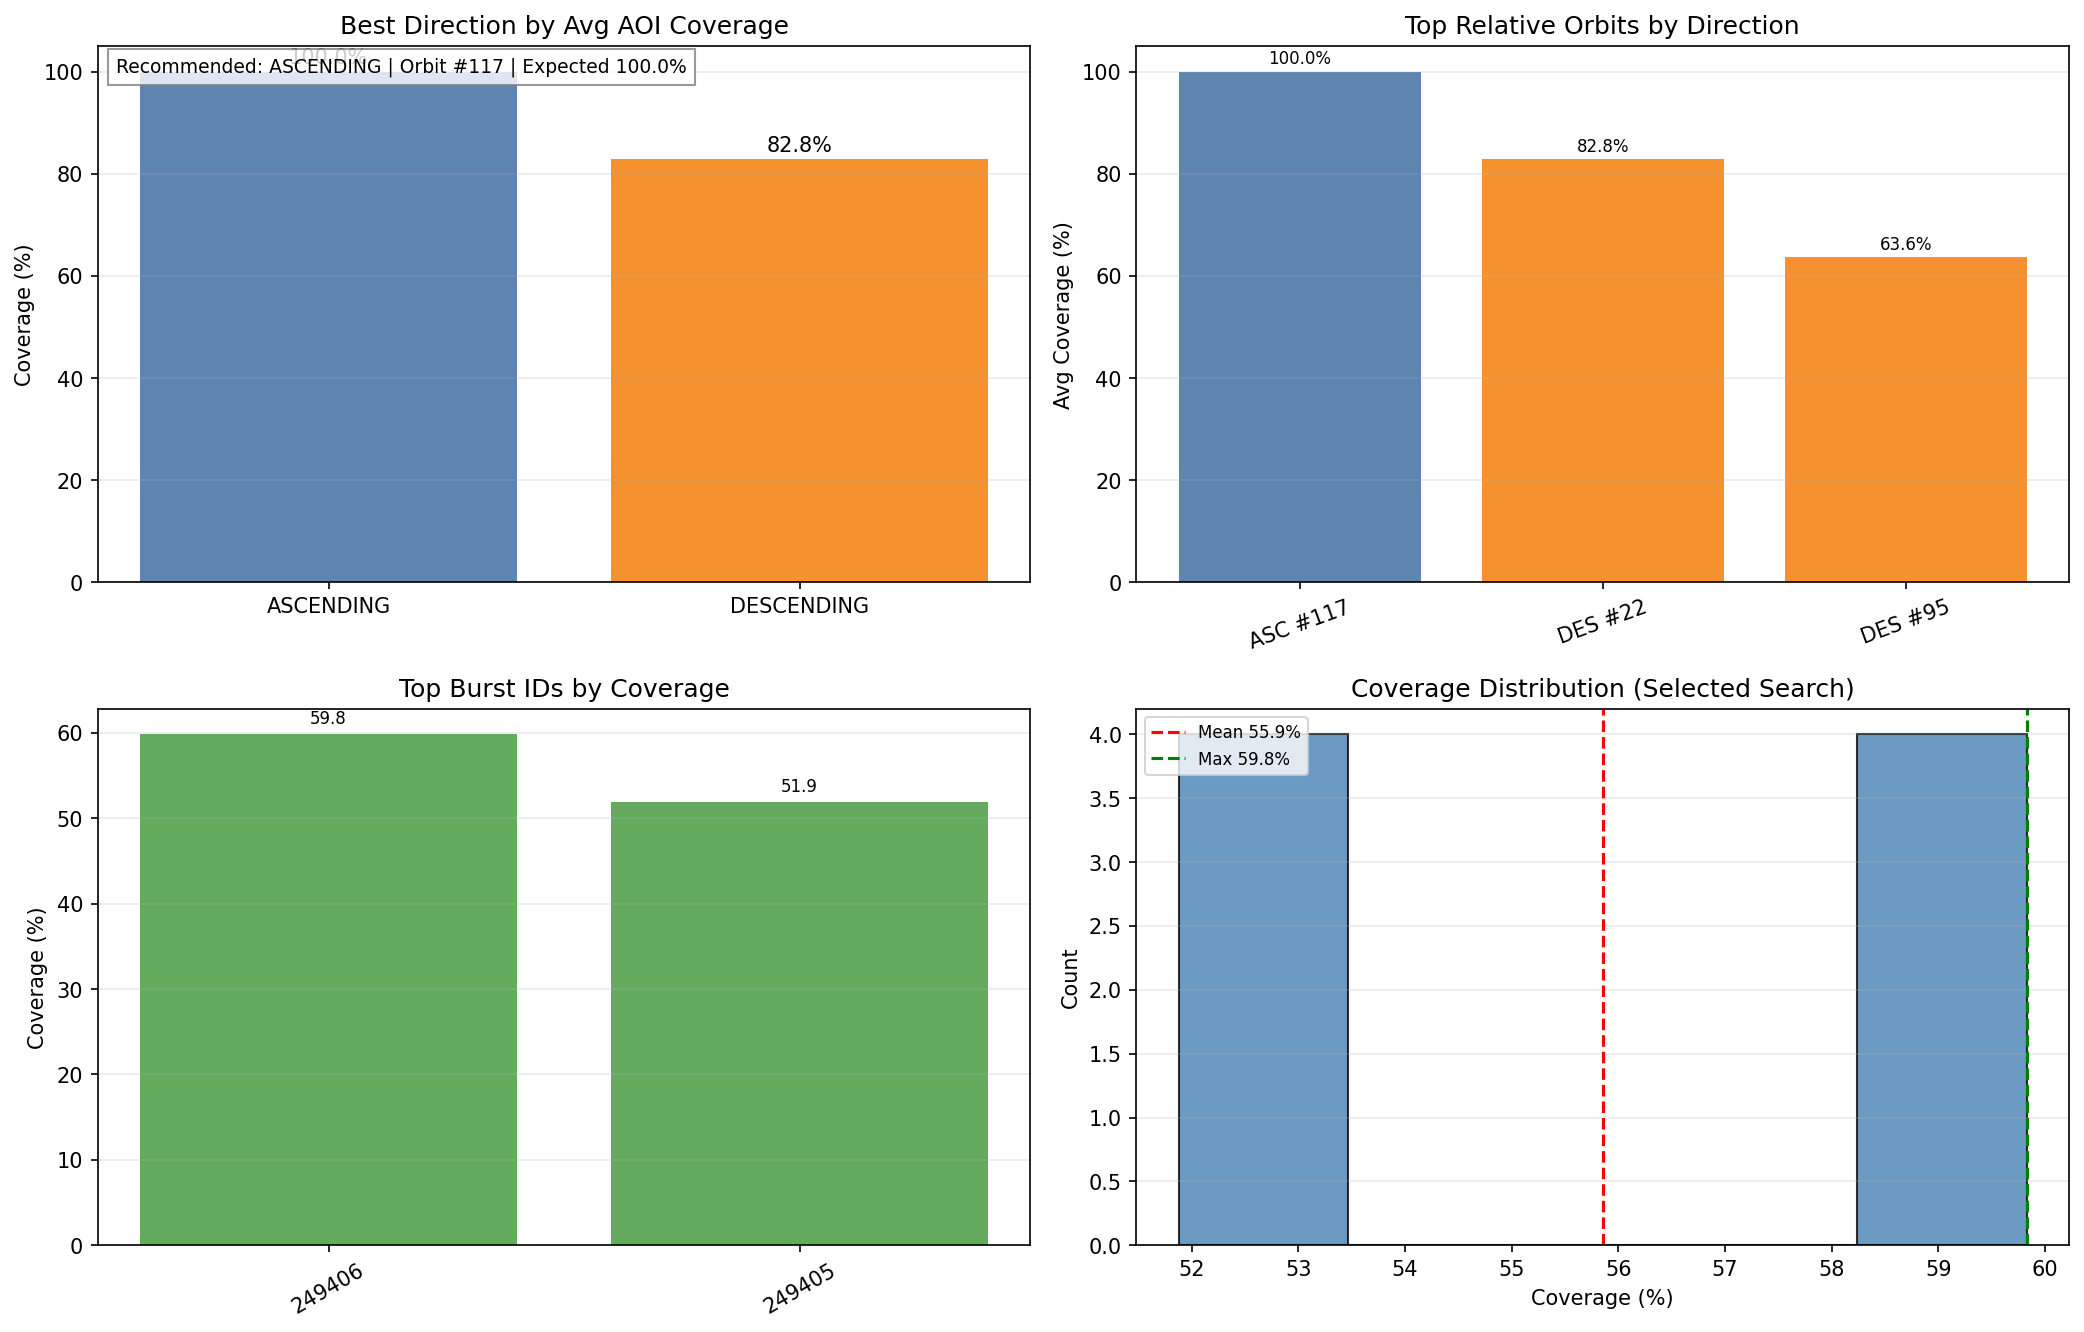

In [4]:
assert validation["ok"], f"Validation failed: {validation['errors']}"
display(df.head(10))

coverage_plot = paths.get("coverage_plot_png")
if coverage_plot:
    display(Image(filename=Path(coverage_plot).as_posix()))

df_map = df.copy()
if "coverage" in df_map.columns:
    df_map["coverage"] = pd.to_numeric(df_map["coverage"], errors="coerce")
    df_map = df_map[df_map["coverage"] > 0].copy()

burst_map = plot_product_footprints(
    df=df_map,
    aoi_wkt=AOI_WKT,
    top_n=len(df_map) if len(df_map) else 1,
    name_col="ParentProductName",
    id_col="Id",
    group_by="product",
    add_layer_control=True,
)
burst_map


## Resolve the Burst Pair

When no manual UUIDs are provided, `select_burst_pair(...)` groups results by `BurstId`, `SwathIdentifier`, `RelativeOrbitNumber`, `OrbitDirection`, and `PolarisationChannels`, then ranks by max coverage and recency. The most recent acquisition becomes the master.


In [5]:
selection = select_burst_pair(
    df,
    master_id=MASTER_BURST_UUID,
    slave_id=SLAVE_BURST_UUID,
)

MASTER_BURST_ID = selection.master.id
SLAVE_BURST_ID = selection.slave.id

display(pd.DataFrame([
    {
        "role": "master",
        "id": selection.master.id,
        "burst_id": selection.master.burst_id,
        "swath": selection.master.swath_identifier,
        "relative_orbit": selection.master.relative_orbit_number,
        "orbit_direction": selection.master.orbit_direction,
        "polarisation": selection.master.polarisation_channels,
        "parent_product": selection.master.parent_product_name,
        "content_start": selection.master.content_start.isoformat(),
        "coverage": selection.master.coverage,
    },
    {
        "role": "slave",
        "id": selection.slave.id,
        "burst_id": selection.slave.burst_id,
        "swath": selection.slave.swath_identifier,
        "relative_orbit": selection.slave.relative_orbit_number,
        "orbit_direction": selection.slave.orbit_direction,
        "polarisation": selection.slave.polarisation_channels,
        "parent_product": selection.slave.parent_product_name,
        "content_start": selection.slave.content_start.isoformat(),
        "coverage": selection.slave.coverage,
    },
]))


,role,id,burst_id,swath,relative_orbit,orbit_direction,polarisation,parent_product,content_start,coverage
0,master,8ff4f2b3-64d8-4852-8c3b-4b2b8f729b03,249406,IW2,117,ASCENDING,VV,S1A_IW_SLC__1SDV_20250217T170559_20250217T1706...,2025-02-17T17:06:13.727886+00:00,59.83
1,slave,2404a519-5e05-4dcc-95e5-b3e4e8a79127,249406,IW2,117,ASCENDING,VV,S1A_IW_SLC__1SDV_20250205T170559_20250205T1706...,2025-02-05T17:06:14.317745+00:00,59.83


## Download and Extract Bursts

Burst products are requested through the CDSE burst processing endpoint, not via `.s5cfg` / S3. This cell reuses a single archive already present in the role-specific folder, otherwise it requests the burst on demand and then extracts it to one `.SAFE` root.


In [6]:
ACCESS_TOKEN = None


def ensure_burst_archive(burst_uuid: str, role: str) -> Path:
    global ACCESS_TOKEN
    role_dir = BURST_DIR / role / burst_uuid
    role_dir.mkdir(parents=True, exist_ok=True)

    existing = sorted(role_dir.glob("*.zip"))
    if len(existing) == 1:
        return existing[0]
    if len(existing) > 1:
        raise RuntimeError(f"Expected at most one cached archive in {role_dir}, found {len(existing)}")

    if not CDSE_USERNAME or not CDSE_PASSWORD:
        raise ValueError("Set CDSE_USERNAME/CDSE_PASSWORD or CDSE_USR/CDSE_PSW before downloading bursts")

    if ACCESS_TOKEN is None:
        ACCESS_TOKEN = get_token(username=CDSE_USERNAME, password=CDSE_PASSWORD)

    download_burst_on_demand(burst_id=burst_uuid, token=ACCESS_TOKEN, output_dir=role_dir)

    refreshed = sorted(role_dir.glob("*.zip"))
    if len(refreshed) != 1:
        raise RuntimeError(
            f"Expected exactly one burst archive after download in {role_dir}, found {len(refreshed)}"
        )
    return refreshed[0]


MASTER_ARCHIVE = ensure_burst_archive(MASTER_BURST_ID, "master")
SLAVE_ARCHIVE = ensure_burst_archive(SLAVE_BURST_ID, "slave")

MASTER_PRODUCT = extract_burst_archive(MASTER_ARCHIVE, BURST_DIR / "extracted" / "master" / MASTER_BURST_ID)
SLAVE_PRODUCT = extract_burst_archive(SLAVE_ARCHIVE, BURST_DIR / "extracted" / "slave" / SLAVE_BURST_ID)

print(json.dumps({
    "master_archive": MASTER_ARCHIVE.as_posix(),
    "slave_archive": SLAVE_ARCHIVE.as_posix(),
    "master_product": MASTER_PRODUCT.as_posix(),
    "slave_product": SLAVE_PRODUCT.as_posix(),
}, indent=2))


{
  "master_archive": "/shared/home/rdelprete/PythonProjects/srp/data/bursts/master/8ff4f2b3-64d8-4852-8c3b-4b2b8f729b03/S1A_SLC_20250217T170613_249406_IW2_VV_468546.zip",
  "slave_archive": "/shared/home/rdelprete/PythonProjects/srp/data/bursts/slave/2404a519-5e05-4dcc-95e5-b3e4e8a79127/S1A_SLC_20250205T170614_249406_IW2_VV_466741.zip",
  "master_product": "/shared/home/rdelprete/PythonProjects/srp/data/bursts/extracted/master/8ff4f2b3-64d8-4852-8c3b-4b2b8f729b03/S1A_SLC_20250217T170613_249406_IW2_VV_468546/S1A_SLC_20250217T170613_249406_IW2_VV_468546.SAFE",
  "slave_product": "/shared/home/rdelprete/PythonProjects/srp/data/bursts/extracted/slave/2404a519-5e05-4dcc-95e5-b3e4e8a79127/S1A_SLC_20250205T170614_249406_IW2_VV_466741/S1A_SLC_20250205T170614_249406_IW2_VV_466741.SAFE"
}


## Burst-Native Processing Configuration

These settings keep the burst workflow simple and explicit:
- `Apply-Orbit-File` runs on each extracted burst product independently
- `TOPSAR-Split` is skipped because each input is already a single burst product
- `use_esd=False` is passed to `topsar_coregistration(...)`
- `subset` is optional and disabled by default because the burst is already spatially focused


In [7]:
DEM_NAME = "Copernicus 30m Global DEM"
PIXEL_SPACING_M = 14.0
SUBSET_REGION = None

if not GPT_PATH.exists():
    print(f"SNAP gpt not found at {GPT_PATH}. Update GPT_PATH before running processing cells.")


## Run SNAPFlow Processing

The output sequence is:
- orbit-correct master burst
- orbit-correct slave burst
- pairwise coregistration with `use_esd=False`
- deburst
- interferogram
- topo phase removal
- optional subset
- terrain correction


In [8]:
def build_gpt(product: str | Path, outdir: str | Path) -> GPT:
    return GPT(
        product=product,
        outdir=outdir,
        format="BEAM-DIMAP",
        gpt_path=GPT_PATH.as_posix(),
        snap_userdir=SNAP_USERDIR,
    )


def ensure_orbit_product(product: Path, role: str) -> Path:
    role_dir = PROCESS_DIR / role
    target = role_dir / f"{product.stem}_ORB.dim"
    if target.exists():
        return target

    gpt = build_gpt(product, role_dir)
    orbit_path = gpt.apply_orbit_file(output_name=f"{product.stem}_ORB")
    if orbit_path is None:
        raise RuntimeError(gpt.last_error_summary())
    return Path(orbit_path)


prepared_master = ensure_orbit_product(MASTER_PRODUCT, "master")
prepared_slave = ensure_orbit_product(SLAVE_PRODUCT, "slave")

pair_outdir = PROCESS_DIR / "pair"
pair_gpt = build_gpt(prepared_master, pair_outdir)

coreg_target = pair_outdir / "pair_coreg.dim"
if coreg_target.exists():
    pair_gpt.prod_path = coreg_target
    coreg_path = coreg_target.as_posix()
else:
    coreg_path = pair_gpt.topsar_coregistration(
        master_product=prepared_master,
        slave_product=prepared_slave,
        use_esd=False,
        dem_name=DEM_NAME,
        output_name="pair_coreg",
        keep_graph=True,
    )
    if coreg_path is None:
        raise RuntimeError(pair_gpt.last_error_summary())

deburst_target = pair_outdir / "pair_coreg_deb.dim"
if deburst_target.exists():
    pair_gpt.prod_path = deburst_target
    deburst_path = deburst_target.as_posix()
else:
    deburst_path = pair_gpt.deburst(output_name="pair_coreg_deb")
    if deburst_path is None:
        raise RuntimeError(pair_gpt.last_error_summary())

ifg_target = pair_outdir / "pair_ifg.dim"
if ifg_target.exists():
    pair_gpt.prod_path = ifg_target
    ifg_path = ifg_target.as_posix()
else:
    ifg_path = pair_gpt.interferogram(
        subtract_flat_earth_phase=True,
        include_coherence=True,
        output_name="pair_ifg",
    )
    if ifg_path is None:
        raise RuntimeError(pair_gpt.last_error_summary())

topo_target = pair_outdir / "pair_ifg_topo.dim"
if topo_target.exists():
    pair_gpt.prod_path = topo_target
    topo_path = topo_target.as_posix()
else:
    topo_path = pair_gpt.topo_phase_removal(
        dem_name=DEM_NAME,
        output_name="pair_ifg_topo",
    )
    if topo_path is None:
        raise RuntimeError(pair_gpt.last_error_summary())

subset_path = None
terrain_source = Path(topo_path)
if SUBSET_REGION:
    subset_target = pair_outdir / "pair_ifg_subset.dim"
    if subset_target.exists():
        pair_gpt.prod_path = subset_target
        subset_path = subset_target.as_posix()
    else:
        subset_path = pair_gpt.subset(
            region=SUBSET_REGION,
            copy_metadata=True,
            output_name="pair_ifg_subset",
        )
        if subset_path is None:
            raise RuntimeError(pair_gpt.last_error_summary())
    terrain_source = Path(subset_path)

terrain_gpt = build_gpt(terrain_source, pair_outdir)
terrain_target = pair_outdir / "pair_ifg_tc.dim"
if terrain_target.exists():
    terrain_path = terrain_target.as_posix()
else:
    terrain_path = terrain_gpt.terrain_correction(
        dem_name=DEM_NAME,
        pixel_spacing_in_meter=PIXEL_SPACING_M,
        save_selected_source_band=True,
        save_local_incidence_angle=True,
        output_name="pair_ifg_tc",
    )
    if terrain_path is None:
        raise RuntimeError(terrain_gpt.last_error_summary())

PROCESS_OUTPUTS = {
    "prepared_master": prepared_master.as_posix(),
    "prepared_slave": prepared_slave.as_posix(),
    "coregistration": coreg_path,
    "deburst": deburst_path,
    "interferogram": ifg_path,
    "topo_phase_removal": topo_path,
    "subset": subset_path,
    "terrain_correction": terrain_path,
}

print(json.dumps(PROCESS_OUTPUTS, indent=2))


{
  "prepared_master": "/shared/home/rdelprete/PythonProjects/srp/data/output/snapflow_v2/processing/master/S1A_SLC_20250217T170613_249406_IW2_VV_468546_ORB.dim",
  "prepared_slave": "/shared/home/rdelprete/PythonProjects/srp/data/output/snapflow_v2/processing/slave/S1A_SLC_20250205T170614_249406_IW2_VV_466741_ORB.dim",
  "coregistration": "/shared/home/rdelprete/PythonProjects/srp/data/output/snapflow_v2/processing/pair/pair_coreg.dim",
  "deburst": "/shared/home/rdelprete/PythonProjects/srp/data/output/snapflow_v2/processing/pair/pair_coreg_deb.dim",
  "interferogram": "/shared/home/rdelprete/PythonProjects/srp/data/output/snapflow_v2/processing/pair/pair_ifg.dim",
  "topo_phase_removal": "/shared/home/rdelprete/PythonProjects/srp/data/output/snapflow_v2/processing/pair/pair_ifg_topo.dim",
  "subset": null,
  "terrain_correction": "/shared/home/rdelprete/PythonProjects/srp/data/output/snapflow_v2/processing/pair/pair_ifg_tc.dim"
}


## Preview Outputs

This cell renders quicklook visuals from the generated ENVI rasters, including wrapped phase, coherence, and terrain-corrected support layers.


stage,product,exists,band_preview
prepared_master,S1A_SLC_20250217T170613_249406_IW2_VV_468546_ORB.dim,True,"i_IW2_VV, q_IW2_VV"
prepared_slave,S1A_SLC_20250205T170614_249406_IW2_VV_466741_ORB.dim,True,"i_IW2_VV, q_IW2_VV"
coregistration,pair_coreg.dim,True,"i_IW2_VV_mst_17Feb2025, i_IW2_VV_slv1_05Feb2025, q_IW2_VV_mst_17Feb2025, q_IW2_VV_slv1_05Feb2025"
deburst,pair_coreg_deb.dim,True,"i_IW2_VV_mst_17Feb2025, i_IW2_VV_slv1_05Feb2025, q_IW2_VV_mst_17Feb2025, q_IW2_VV_slv1_05Feb2025"
interferogram,pair_ifg.dim,True,"coh_IW2_VV_17Feb2025_05Feb2025, i_ifg_IW2_VV_17Feb2025_05Feb2025, q_ifg_IW2_VV_17Feb2025_05Feb2025"
topo_phase_removal,pair_ifg_topo.dim,True,"coh_IW2_VV_17Feb2025_05Feb2025, i_ifg_VV_17Feb2025_05Feb2025, q_ifg_VV_17Feb2025_05Feb2025"
terrain_correction,pair_ifg_tc.dim,True,"coh_IW2_VV_17Feb2025_05Feb2025, elevation, i_ifg_VV_17Feb2025_05Feb2025, localIncidenceAngle, q_ifg_VV_17Feb2025_05Feb2025"


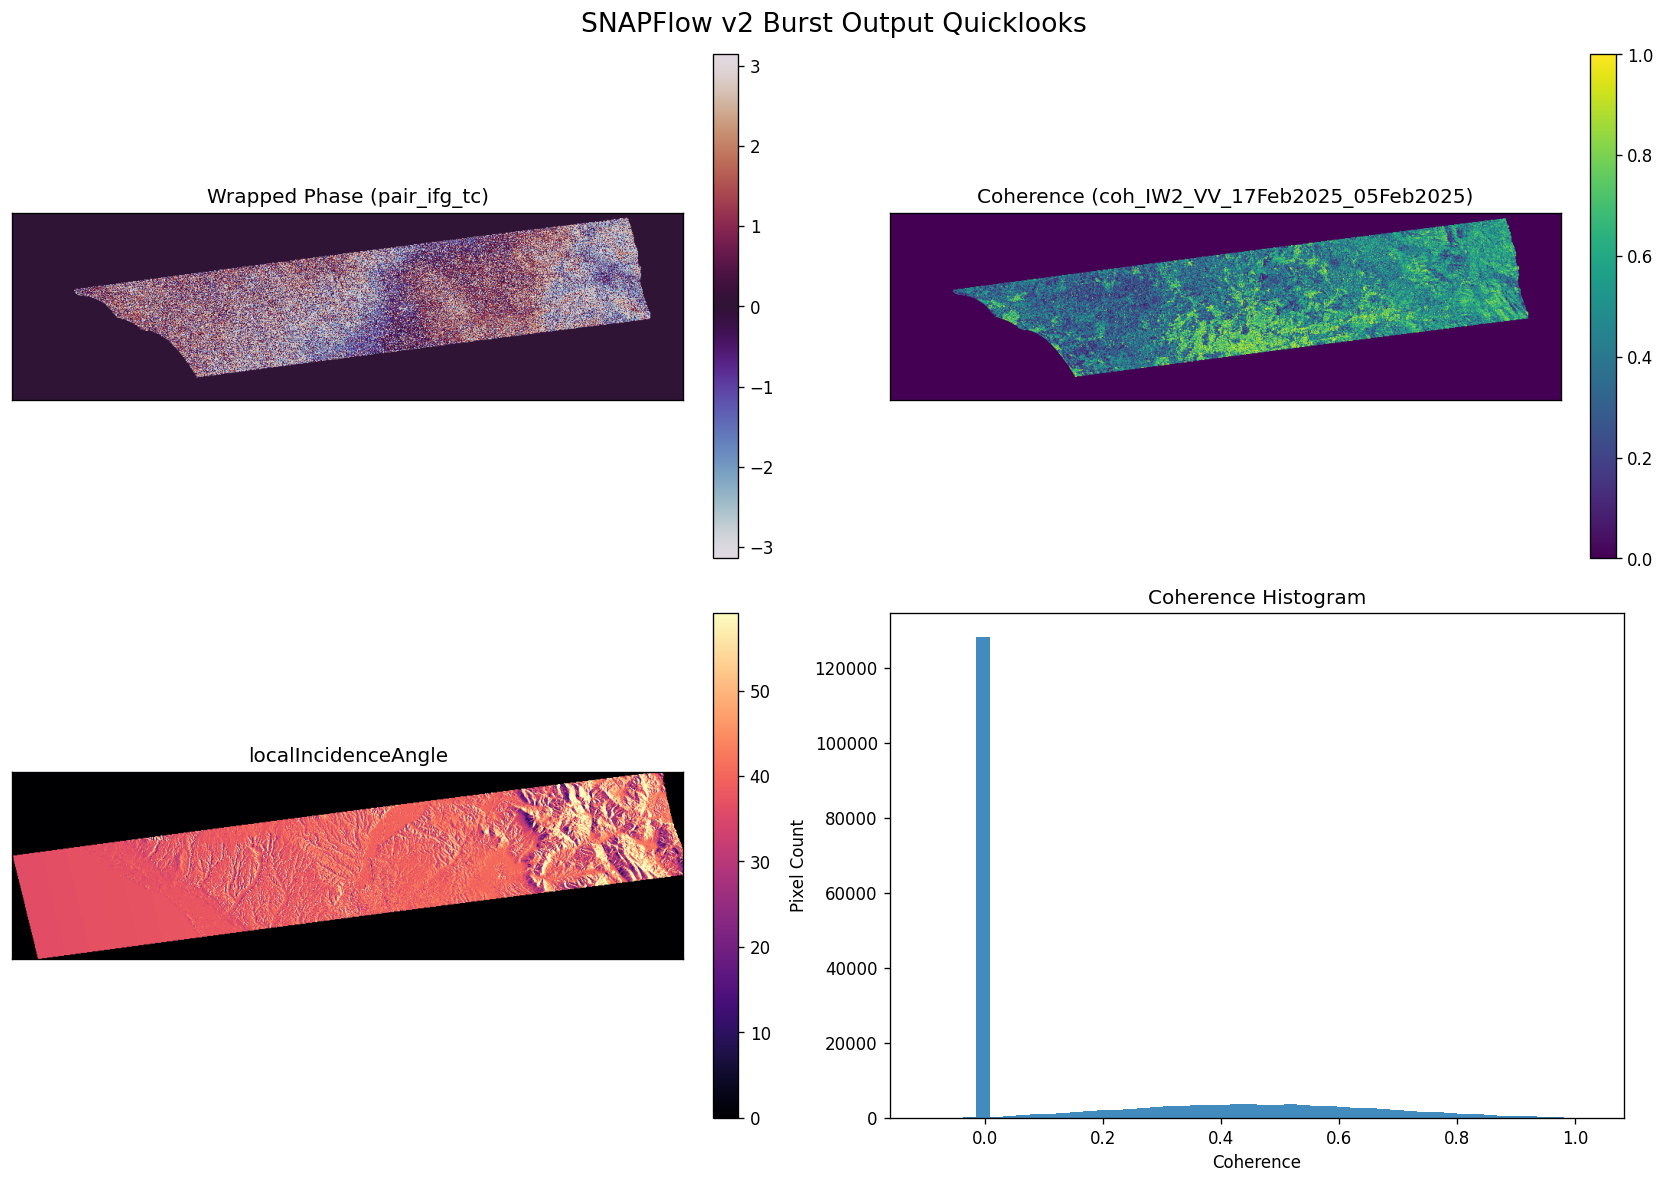

In [9]:
import matplotlib.pyplot as plt
import numpy as np

ENVI_DTYPE_MAP = {
    "1": np.uint8,
    "2": np.int16,
    "3": np.int32,
    "4": np.float32,
    "5": np.float64,
    "6": np.complex64,
    "9": np.complex128,
    "12": np.uint16,
    "13": np.uint32,
    "14": np.int64,
    "15": np.uint64,
}


def data_dir_for(product_path: str | Path) -> Path:
    return Path(product_path).with_suffix(".data")


def parse_envi_header(hdr_path: str | Path) -> dict[str, str]:
    values: dict[str, str] = {}
    for line in Path(hdr_path).read_text().splitlines():
        if " = " not in line:
            continue
        key, value = line.split(" = ", 1)
        values[key.strip().lower()] = value.strip().strip("{}")
    required = ["samples", "lines", "bands", "data type", "byte order"]
    missing = [key for key in required if key not in values]
    if missing:
        raise ValueError(f"Missing ENVI metadata in {hdr_path}: {missing}")
    return values


def read_envi_quicklook(img_path: str | Path, max_side: int = 900) -> np.ndarray:
    img_path = Path(img_path)
    header = parse_envi_header(img_path.with_suffix(".hdr"))
    samples = int(header["samples"])
    lines = int(header["lines"])
    bands = int(header["bands"])
    if bands != 1:
        raise ValueError(f"Preview helper expects single-band rasters, got {bands} for {img_path}")
    dtype = np.dtype(ENVI_DTYPE_MAP[header["data type"]])
    if header["byte order"] == "1":
        dtype = dtype.newbyteorder(">")
    array = np.memmap(img_path, dtype=dtype, mode="r", shape=(lines, samples))
    step = max(1, int(np.ceil(max(lines, samples) / max_side)))
    return np.asarray(array[::step, ::step], dtype=np.float32)


def first_matching_band(product_path: str | Path, *needles: str) -> Path | None:
    data_dir = data_dir_for(product_path)
    if not data_dir.exists():
        return None
    candidates = sorted(data_dir.glob("*.img"))
    lowered = [(path, path.name.lower()) for path in candidates]
    for needle in needles:
        target = needle.lower()
        for path, lower_name in lowered:
            if target in lower_name:
                return path
    return None


def wrapped_phase(i_band: str | Path, q_band: str | Path, max_side: int = 900) -> np.ndarray:
    i_data = read_envi_quicklook(i_band, max_side=max_side)
    q_data = read_envi_quicklook(q_band, max_side=max_side)
    return np.arctan2(q_data, i_data)


def robust_limits(array: np.ndarray, low: float = 2.0, high: float = 98.0) -> tuple[float, float]:
    valid = array[np.isfinite(array)]
    if valid.size == 0:
        return (0.0, 1.0)
    lo, hi = np.nanpercentile(valid, [low, high])
    if float(lo) == float(hi):
        hi = lo + 1.0
    return float(lo), float(hi)


def preview_band_list(product_path: str | Path, limit: int = 6) -> str:
    bands = sorted(path.stem for path in data_dir_for(product_path).glob("*.img"))
    if not bands:
        return ""
    if len(bands) <= limit:
        return ", ".join(bands)
    return ", ".join(bands[:limit]) + f", ... (+{len(bands) - limit} more)"


summary_rows = []
for label, product_path in PROCESS_OUTPUTS.items():
    if not product_path:
        continue
    product = Path(product_path)
    summary_rows.append({
        "stage": label,
        "product": product.name,
        "exists": product.exists(),
        "band_preview": preview_band_list(product),
    })

display(pd.DataFrame(summary_rows))

terrain_product = Path(PROCESS_OUTPUTS["terrain_correction"])
topo_product = Path(PROCESS_OUTPUTS["topo_phase_removal"])
ifg_product = Path(PROCESS_OUTPUTS["interferogram"])

phase_product = terrain_product if terrain_product.exists() else topo_product
phase_i = first_matching_band(phase_product, "i_ifg_")
phase_q = first_matching_band(phase_product, "q_ifg_")
coherence_band = (
    first_matching_band(terrain_product, "coh_")
    or first_matching_band(topo_product, "coh_")
    or first_matching_band(ifg_product, "coh_")
)
incidence_band = first_matching_band(terrain_product, "localincidenceangle")
elevation_band = first_matching_band(terrain_product, "elevation")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("SNAPFlow v2 Burst Output Quicklooks", fontsize=16)

if phase_i and phase_q:
    phase_data = wrapped_phase(phase_i, phase_q)
    im = axes[0, 0].imshow(phase_data, cmap="twilight", vmin=-np.pi, vmax=np.pi)
    axes[0, 0].set_title(f"Wrapped Phase ({phase_product.stem})")
    fig.colorbar(im, ax=axes[0, 0], fraction=0.046, pad=0.04)
else:
    axes[0, 0].axis("off")
    axes[0, 0].text(0.5, 0.5, "Wrapped phase bands not available", ha="center", va="center")

coherence_data = None
if coherence_band:
    coherence_data = read_envi_quicklook(coherence_band)
    im = axes[0, 1].imshow(coherence_data, cmap="viridis", vmin=0.0, vmax=1.0)
    axes[0, 1].set_title(f"Coherence ({coherence_band.stem})")
    fig.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)
else:
    axes[0, 1].axis("off")
    axes[0, 1].text(0.5, 0.5, "Coherence band not available", ha="center", va="center")

support_band = incidence_band or elevation_band
if support_band:
    support_data = read_envi_quicklook(support_band)
    vmin, vmax = robust_limits(support_data)
    im = axes[1, 0].imshow(support_data, cmap="magma", vmin=vmin, vmax=vmax)
    axes[1, 0].set_title(support_band.stem)
    fig.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)
else:
    axes[1, 0].axis("off")
    axes[1, 0].text(0.5, 0.5, "Terrain support raster not available", ha="center", va="center")

if coherence_data is not None:
    valid = coherence_data[np.isfinite(coherence_data)].ravel()
    axes[1, 1].hist(valid, bins=50, color="#1f77b4", alpha=0.85)
    axes[1, 1].set_title("Coherence Histogram")
    axes[1, 1].set_xlabel("Coherence")
    axes[1, 1].set_ylabel("Pixel Count")
else:
    axes[1, 1].axis("off")
    axes[1, 1].text(0.5, 0.5, "No coherence histogram available", ha="center", va="center")

for axis in (axes[0, 0], axes[0, 1], axes[1, 0]):
    if axis.axison:
        axis.set_xticks([])
        axis.set_yticks([])

plt.tight_layout()
plt.show()
